Valutazione dei modelli
Regressione tramite SVR con confronto del SVR regressor senza il tuning dei parametri e il modello SVR con la Grid Search applicata per ottimizzare questi parametri

REGRESSIONE CON GRID SEARCH

In [1]:
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV


Caricamento dataset

In [2]:
data=fetch_california_housing()
X,y= data.data, data.target

Split dei dati tra train e test

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,shuffle=True,test_size=0.2,random_state=42)

Appliochiamo lo scaling dei dati (da fare dopo lo split)

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train) #dataset di train
X_test_scaled=scaler.transform(X_test) #dataset di test

Modello base senza grid search sugli iperparametri
svr è un algoritmo computazionalmente pesante

In [5]:
svr_base=SVR(kernel="linear",C=1.0, epsilon=0.1)
svr_base.fit(X_train_scaled,y_train)
y_pred_base=svr_base.predict(X_test_scaled)
mse_base=mean_squared_error(y_test,y_pred_base)

Applichiamo pa GridSearchCV

Creazione param_grid (dizionario python chiave e valore)

C= regolarizzazione, quanto vuoi seguire i dati. C basso generalizza meglio (ignori picchi strani), C alto rischia overfitting (insegue anche anomalie).
epsilon: tolleranza all'errore, zona in cui l'errore non conta. 
Epsilon alto= ignori tanti errori, modello semplice
Epsilon basso= vuoi precisione, modello più complesso.

In [6]:
param_grid={"kernel":["linear"],"C":[0.1,1.0,10.0],"epsilon":[0.05,0.1,0.2]}

eseguo la gridsearch 
Prova tutte le combinazioni di parametri passati con param_grid, valuta ogni combinazione con cross-validation ed estrae il migliore con best_estimator_. Il migliore lo recupera in base all'MSE (neg_mean_squared_error). Con cv=5 (cross-validation a 5 fold) divide i dati in 5 pezzi ed ogni combinazione di param_grid viene testata 5 volte, ogni volta cambiando il set di test.
Per ogni combinazione calcola media MSE, alla fine tiene il migliore MSE

In [7]:
grid=GridSearchCV(SVR(),param_grid=param_grid,cv=5,scoring="neg_mean_squared_error")
grid.fit(X_train_scaled,y_train)

best_svr=grid.best_estimator_
y_pred_best=best_svr.predict(X_test_scaled)
mse_best=mean_squared_error(y_test,y_pred_best)

In [8]:
print(f"Migliori parametri:\n{grid.best_params_}")
print(f"MSE (base):\t{mse_base:.4f}")
print(f"MSE (best):\t{mse_best:.4f}")

Migliori parametri:
{'C': 0.1, 'epsilon': 0.2, 'kernel': 'linear'}
MSE (base):	0.5793
MSE (best):	0.5781


Rappresentazione di entrambi i modelli

Uso PCA non per addestrare il modello ma solo per visualizzare.

In [9]:
X_scaled_all=np.vstack([X_train_scaled,X_test_scaled]) #unisce verticalmente (uno sotto l'altro) due array numpy, risultato 1 dataset che contiene train+test
y_all=np.hstack([y_train,y_test])

pca=PCA(n_components=2) #faccio pca solo per la visualizzazione
X_pca=pca.fit_transform(X_scaled_all) #dataset ridotto a solo 2 componenti

In [10]:
X_pca_1=X_pca[:,0].reshape(-1,1) #reshape trasforma array 1d in una colonna 2d -1 vuol dire calcola tu il numero di righe
#senza reshap ho una lista, con rashape ho una tabella con una colonna

svr_base_1d=SVR(kernel="linear",C=1.0,epsilon=0.1) #alleno il modello
svr_base_1d.fit(X_pca_1,y_all)
y_pred_base_1d=svr_base_1d.predict(X_pca_1)

best_svr_1d=SVR(**grid.best_params_) #itera tutte le chiavi di un dizionario, prendendo solo la soluzione migliore con best_ params
best_svr_1d.fit(X_pca_1,y_all)
y_pred_best_1d=best_svr_1d.predict(X_pca_1)


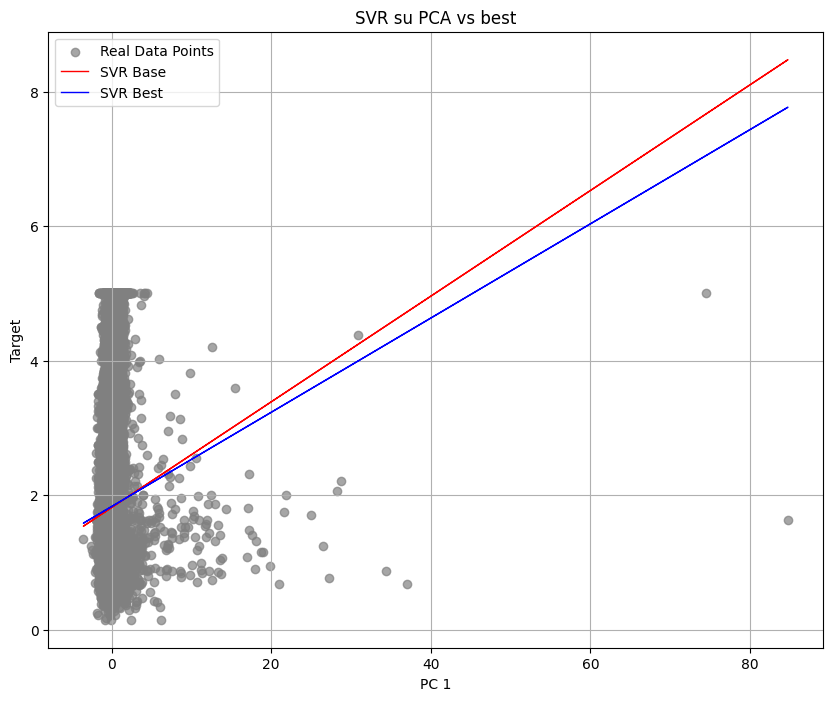

In [11]:
plt.figure(figsize=(10,8))
plt.scatter(X_pca_1,y_all,color="gray",alpha=0.7,label="Real Data Points")
plt.plot(X_pca_1,y_pred_base_1d,color="red",label="SVR Base",linewidth=1)
plt.plot(X_pca_1,y_pred_best_1d,color="blue",label="SVR Best",linewidth=1)
plt.xlabel("PC 1")
plt.ylabel("Target")
plt.title("SVR su PCA vs best")
plt.legend()
plt.grid(True)
plt.show()